ToDo:
- these truth/predicted scatter plots...
    + für spatial mean values
    + für einzelne grid-cells?


- woher stammt varianz?
- varianz für Extremereignisse

changes to implement on server:
- updated utils.torch_to_dataarray()
- added utils.rank_histogram()

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import importlib
import numpy as np
from engression.loss_func import energy_loss, energy_loss_two_sample
import torch
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
import torch, gc
import pickle
import matplotlib.pyplot as plt
import json


device: cpu


# Compare Loss (S1 S2)

# Analogues

In [3]:
# LOAD ORIGINAL DATA

settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)

# Load temperature data
ds_test = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])

x_te = ut.data_to_torch(ds_test, "TREFHT")
x_entire = ut.data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500_eth_test'])#xr.open_dataset("/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/GMT_and_pseudoPCs_EOFs_Z500_5daily_100ensmembers_JJA_not_scaled.nc")
ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500)
print("z500 shape", z500.shape)

z500_test = z500 #[int(-64000):,:]

x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)
x_entire_reduced, mask_x_entire = ut.remove_nan_columns(x_entire)

torch.Size([14307, 1024])
torch.Size([14307, 1024])
z500 shape (14307, 1001)
z500 shape torch.Size([14307, 1001])


In [4]:
#############################
### Choose any Z500 index ###
#############################

# find max NAO index
idx_max_ar = torch.argmax(z500_test, dim=0)
idx_max = idx_max_ar[10]
print(idx_max)

# find min NAO index
idx_min_ar = torch.argmin(z500_test, dim=0)
idx_min = idx_min_ar[0]
print(idx_min)

#index = 46368 #np.random.randint(0, 64000 + 1, size=1)
#idx_max = index

tensor(2871)
tensor(7771)


In [5]:
importlib.reload(ut)

########################
### DPA temperatures ###
########################

# load DPA predicted temperatures
# noise dim = 20
predicts_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/eth_predictions/counterfactual_predictions/"

# noise dim = 100
#predicts_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1_noise1/"
dpa_t_samples_raw, dpa_t_samples, _, _ = ut.load_dpa_predicts(predicts_path, mask_x_te)










1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97


In [6]:
idx_max

tensor(2871)

In [7]:
# extract corresponding DPA ensemble temperatures for Z500 sample
dpa_temps_for_zsample_xr, z500_sample = ut.extract_dpa_tsamples(z500_test, dpa_t_samples_raw, idx_max, coord_ds=ds_test, mask=mask_x_te)
dpa_temps_for_zsample_xr

(97, 1024)
<class 'torch.Tensor'>
input array is numpy array


<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, time: 97)> Size: 795kB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 1.21799994,  4.28467417,  4.03399515, ...,  2.76122808,
          0.98143017,  2.835639  ],
        [ 1.08600533,  4.38114262,  4.44337606, ...,  2.83216858,
          1.38660538,  3.57841158],
        [ 1.58514678,  5.35442638,  4.28060722, ...,  2.78188848,
          1.93762028,  3.50137329]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 1.12065279,  4.26161575,  4.13674068, ...,  2.41775441,
          0.96381891,  2.97528815],
        [ 1.37773681,  5.22272491,  4.74392939, ...,  2.7349062 ,
          1.66509151,  3.50759959],
        [ 2.0576725 ,  5.58455992,  5.34200478, ...,  2.45157313,
          1.61539006,  3.8607955 ]]], shape=(32, 32, 97))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) int64 776B 0 1 2 3 4 5 6 7 8 ... 88 89 90 91 92 93 94 95 96

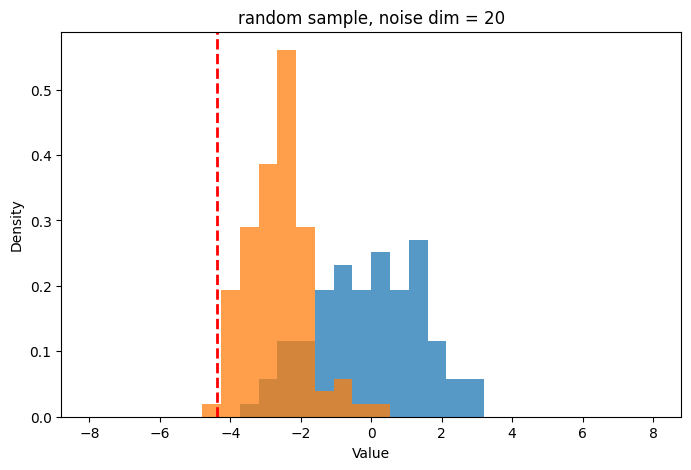

In [8]:
importlib.reload(ut)

##############################
### Create Analogues ###
##############################

# extract analogue temperatures from LE 
nearest_temps, top_idxs = ut.find_analogues(ds_test.TREFHT, ds_z500_pre.pseudo_pcs.values, z500_sample, no_pcs = 100, no_nearest = 97)

############################################
### Compute spatial temperature averages ###
############################################
# GERMANY
## DPA averages
dpa_ger_avgs_pre = dpa_temps_for_zsample_xr.sel(lat=slice(48,54), lon=slice(6,15))

# 1) define weights as above
weights_ger = np.cos(np.deg2rad(dpa_ger_avgs_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': dpa_ger_avgs_pre['lat']}, dims=['lat'])

dpa_ger_avgs = dpa_ger_avgs_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))

## Analogue averages
analogue_ger_avgs = nearest_temps.sel(lat=slice(48,54), lon=slice(6,15)).weighted(w_da_ger).mean(dim=('lat', 'lon'))

#############################
### Compare distributions ###
#############################
ds_true = ds_test
value_min, value_max = -8.0, 8.0
index = idx_max
# WEIGHTS must be compatible with DPA/ANALOG samples
ut.plot_2_distr(idx_max, dpa_ger_avgs, analogue_ger_avgs, ds_true, w_da_ger, vmin=-8.0, vmax=8.0, title = "random sample, noise dim = 20")

# Rank Histograms - all timesteps

## Germany average

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96


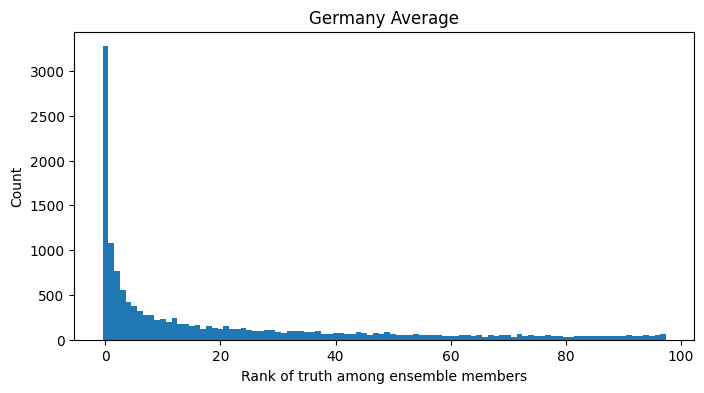

In [9]:
importlib.reload(ut)

ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# true temperature - germany spatial average
temp_true_pre = ds_test.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': dpa_ger_avgs_pre['lat']}, dims=['lat'])

temp_true = temp_true_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))



# DPA predicted average temperatures
dpa_t_samples_weighted_ger_avgs = np.zeros((14307,97))#[]
for i in range(len(dpa_t_samples_raw)):
    print(i)
    # load DPA prediction
    #t_sample = torch.load(f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i}_te.pt", map_location=torch.device('cpu'))
    t_sample = dpa_t_samples_raw[i]
    
    # restore original. shape (32 by 32)
    dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    
    # turn into xarray
    dpa_t_sample_restored_xr = ut.torch_to_dataarray(dpa_t_sample_restored.detach(), ds_test, lat_dim=32, lon_dim=32, name="TREFHT")
    
    # compute weighted germany spatial average
    ger_avg = dpa_t_sample_restored_xr.sel(lat=slice(48,54), lon=slice(6,15)).weighted(w_da_ger).mean(dim=('lat', 'lon'))
    #print(ger_avg.shape)
    dpa_t_samples_weighted_ger_avgs[:,i-1] = ger_avg


truth = temp_true.TREFHT
ensemble = dpa_t_samples_weighted_ger_avgs

# 2) compute ranks
ranks = ut.rank_histogram(truth, ensemble)
n_members = ensemble.shape[1]

# 3) plot rank histogram
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks, bins=np.arange(n_members+2)-0.5)#, edgecolor='black')
#plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Germany Average')
plt.show()

## Central France-average

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
(14307, 97)
(14307,)
(14307, 97)


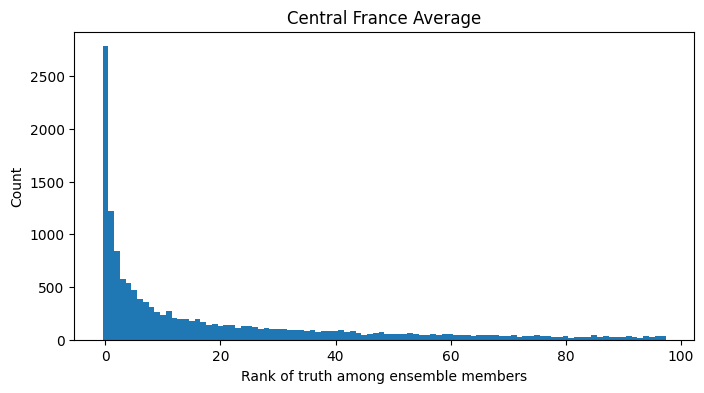

In [10]:
fr_lat_min = 45
fr_lat_max = 50
fr_lon_min = 0
fr_lon_max = 5

# true values - france spatial average
#temp_true_fr = ds_test.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max)).mean(dim=('lat', 'lon'))

# true temperature - germany spatial average
temp_true_pre_fr = ds_test.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max))

# create weights
# 1) define weights as above
weights_fr = np.cos(np.deg2rad(temp_true_pre_fr['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_fr = xr.DataArray(weights_fr, coords={'lat': temp_true_pre_fr['lat']}, dims=['lat'])

temp_true_fr = temp_true_pre_fr.weighted(w_da_fr).mean(dim=('lat', 'lon'))

# DPA predicted values
dpa_t_samples_weighted_fr_avgs = np.zeros((14307,97))

for i in range(len(dpa_t_samples_raw)):
    print(i)
    # load DPA prediction
    t_sample = dpa_t_samples_raw[i]
    #t_sample = torch.load(f"/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/gen{i}_te.pt", map_location=torch.device('cpu'))
    dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    
    # turn into xarray
    dpa_t_sample_restored_xr = ut.torch_to_dataarray(dpa_t_sample_restored.detach(), ds_test, lat_dim=32, lon_dim=32, name="TREFHT")
    
    # compute germany spatial average
    ger_avg = dpa_t_sample_restored_xr.sel(lat=slice(fr_lat_min,fr_lat_max), lon=slice(fr_lon_min,fr_lon_max)).weighted(w_da_fr).mean(dim=('lat', 'lon'))
    #print(ger_avg.shape)
    dpa_t_samples_weighted_fr_avgs[:,i-1] = ger_avg

print(dpa_t_samples_weighted_fr_avgs.shape)

print(temp_true_fr.TREFHT.shape)
print(dpa_t_samples_weighted_fr_avgs.shape)

truth_fr = temp_true_fr.TREFHT
ensemble_fr = dpa_t_samples_weighted_fr_avgs

# 2) compute ranks
ranks = ut.rank_histogram(truth_fr, ensemble_fr)

# 3) plot histogram of ranks
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks, bins=np.arange(n_members+2)-0.5)#, edgecolor='black')
#plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Central France Average')
plt.show()

# --> looks like a bias, DPA overestimates values

## Spain

In [9]:
ds_test

<xarray.Dataset> Size: 263MB
Dimensions:  (lat: 32, lon: 32, time: 64000)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 262MB ...

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96


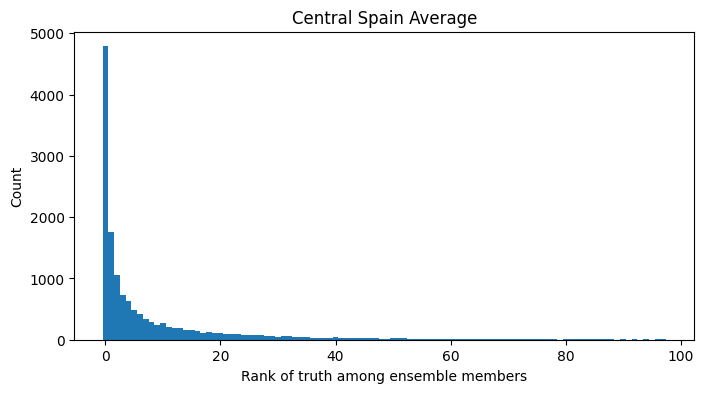

In [11]:
sp_lat_min = 38
sp_lat_max = 42
sp_lon_min = -8
sp_lon_max = 0

# true values - france spatial average
#temp_true_sp = ds_test.sel(lat=slice(sp_lat_min, sp_lat_max), lon=slice(sp_lon_min, sp_lon_max)).mean(dim=('lat', 'lon'))

# true temperature - germany spatial average
temp_true_pre_sp = ds_test.sel(lat=slice(sp_lat_min, sp_lat_max), lon=slice(sp_lon_min, sp_lon_max))

# create weights
# 1) define weights as above
weights_sp = np.cos(np.deg2rad(temp_true_pre_sp['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_sp = xr.DataArray(weights_sp, coords={'lat': temp_true_pre_sp['lat']}, dims=['lat'])

temp_true_sp = temp_true_pre_sp.weighted(w_da_sp).mean(dim=('lat', 'lon'))

# DPA predicted values
dpa_t_samples_weighted_sp_avgs = np.zeros((14307,97))#[]
for i in range(len(dpa_t_samples_raw)):
    print(i)
    # load DPA prediction
    t_sample = dpa_t_samples_raw[i]
    
    #t_sample = torch.load(f"/Users/friederl/Documents/EcoN_project/LLAAE/DPA/tuning_model3/gen{i}_te.pt", map_location=torch.device('cpu'))
    dpa_t_sample_restored = ut.restore_nan_columns(t_sample, mask_x_te)
    
    # turn into xarray
    dpa_t_sample_restored_xr = ut.torch_to_dataarray(dpa_t_sample_restored.detach(), ds_test, lat_dim=32, lon_dim=32, name="TREFHT")
    
    # compute germany spatial average
    sp_avg = dpa_t_sample_restored_xr.sel(lat=slice(sp_lat_min,sp_lat_max), lon=slice(sp_lon_min,sp_lon_max)).weighted(w_da_sp).mean(dim=('lat', 'lon'))
    #print(ger_avg.shape)
    dpa_t_samples_weighted_sp_avgs[:,i-1] = sp_avg

truth_sp = temp_true_sp.TREFHT
ensemble_sp = dpa_t_samples_weighted_sp_avgs

# 2) compute ranks
ranks_sp = ut.rank_histogram(truth_sp, ensemble_sp)

# 3) plot histogram of ranks
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks_sp, bins=np.arange(n_members+2)-0.5)#, edgecolor='black')
#plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Central Spain Average')
plt.show()

# --> looks like a bias, DPA overestimates values

## On grid-cell level

In [3]:
arr_restored = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ens_97_arr_restored.pt", map_location=torch.device('cpu'))
arr_restored.shape

torch.Size([98, 64000, 1024])

In [ ]:
# true temperature



truth_sp = ds_test_masked[]
ensemble_sp = 

# 2) compute ranks
ranks_sp = ut.rank_histogram(truth_sp, ensemble_sp)

# 3) plot histogram of ranks
plt.figure(figsize=(8,4))
# bins from 0..n_members inclusive
plt.hist(ranks_sp, bins=np.arange(n_members+2)-0.5)#, edgecolor='black')
#plt.xticks(np.arange(n_members+1))
plt.xlabel('Rank of truth among ensemble members')
plt.ylabel('Count')
plt.title('Central France Average')
plt.show()

In [4]:
ds_test_masked = x_te[:, mask_x_entire]
ds_test_masked.shape

NameError: name 'x_te' is not defined

In [15]:
len(dpa_t_samples_raw)

97

In [ ]:
x_try = torch.stack(dpa_t_samples_raw, dim=0)
x_try

In [10]:
print(dpa_t_samples_raw.shape)
print(ds_test_masked)

NameError: name 'dpa_t_samples_raw' is not defined